In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [37]:
df = pd.read_csv("../../data/course_lead_scoring.csv" )

In [38]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [39]:
categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)
numerical_columns = list(df.dtypes[df.dtypes != 'object'].index)
numerical_columns =  [x for x in numerical_columns if x != 'converted']

for col in categorical_columns:
    df[col] = df[col].fillna('NA')
    
for col in [numerical_columns]:
    df[col] = df[col].fillna(0)

In [40]:
df.isna().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [85]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
y_full_train = df_full_train.converted.values
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values
del(df_train['converted'])
del(df_test['converted'])
del(df_val['converted'])
len(df_train), len (df_val), len(df_test)

(876, 293, 293)

In [43]:
from sklearn.metrics import accuracy_score

In [16]:
from sklearn.metrics import roc_auc_score

In [17]:
for col in numerical_columns:
    auc = roc_auc_score(y_train, df_train[col])
    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[col])
    print (col, auc)

number_of_courses_viewed 0.7635680590007088
annual_income 0.5519578313253012
interaction_count 0.738270176293409
lead_score 0.6144993577250176


In [54]:
dv = DictVectorizer(sparse=False)
from sklearn.preprocessing import StandardScaler


train_dict = df_train[categorical_columns + numerical_columns].to_dict(orient='records')
X_train_nonstandard = dv.fit_transform(train_dict)
standard_scaler = StandardScaler()
X_train = standard_scaler.fit_transform(X_train_nonstandard)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [55]:
val_dict = df_val[categorical_columns + numerical_columns].to_dict(orient='records')
X_val_nonstandard = dv.transform(val_dict)
X_val = standard_scaler.transform(X_val_nonstandard)
y_pred = model.predict_proba(X_val)[:, 1]

In [56]:
auc = roc_auc_score(y_val, y_pred)
round(auc, 3)

0.921

In [66]:
scores = []
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    tp = ((y_pred >= t) & (y_val == 1)).sum()
    fp = ((y_pred >= t) & (y_val == 0)).sum()
    fn = ((y_pred < t) & (y_val == 1)).sum()
    tn = ((y_pred < t) & (y_val == 0)).sum()

    scores.append((t, tp, fp, fn, tn))

df_scores = pd.DataFrame(scores)
df_scores.columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
df_scores['p'] = df_scores.tp / (df_scores.tp + df_scores.fp)
df_scores['r'] = df_scores.tp / (df_scores.tp + df_scores.fn)


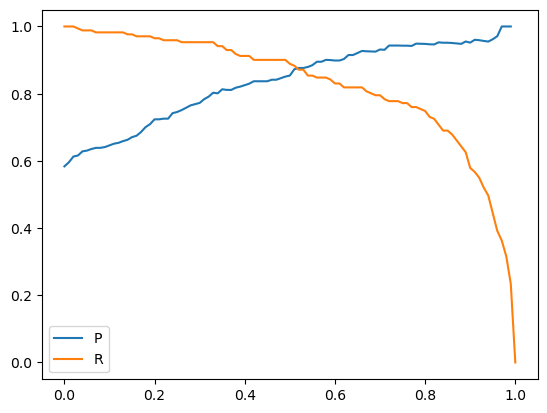

In [67]:
plt.plot(df_scores.threshold, df_scores['p'], label='P')
plt.plot(df_scores.threshold, df_scores['r'], label='R')
plt.legend()

In [69]:
df_scores['f1'] = 2*df_scores.p*df_scores.r / (df_scores.p + df_scores.r)

In [83]:
for t in [0.14, 0.34, 0.54, 0.74]:
    print (t, df_scores[df_scores.threshold == t].f1.values)

0.14 [0.78959811]
0.34 [0.8655914]
0.54 [0.86646884]
0.74 [0.8525641]


In [92]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical_columns + numerical_columns].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train= dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

In [86]:
dv, model = train(df_full_train, y_full_train, C=0.001)

In [87]:
def predict(df, dv, model):
    dicts = df[categorical_columns + numerical_columns].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [88]:
y_pred = predict(df_full_train, dv, model)

In [89]:
from sklearn.model_selection import KFold

In [ ]:
from tqdm.auto import tqdm

In [95]:
n_splits = 5


kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values

    dv, model = train(df_train, y_train, C=C)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

print(np.mean(scores), np.std(scores))

0.8219711164202946 0.035810012684322615


In [98]:
n_splits = 5

for C in [0.000001, 0.001, 1]:
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

C=1e-06 0.560 +- 0.024
C=0.001 0.867 +- 0.029
C=1 0.822 +- 0.036
